# Model Evaluation Notebook
Run this notebook to test your CNN model's performance on a dataset, calculate metrics (Accuracy, F1, Precision, Recall), and plot graphs (ROC Curve, Confusion Matrix).

In [1]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, roc_curve

# Add project root to path so we can import src modules
sys.path.append(os.path.abspath('..'))

from src.models.cnn_model import arsitekturCNN
from src.data.processing import (
    HLA_Dictionary, dictionary, construct_aaindex,
    peptide_iterate, hla_iterate
)
from pathlib import Path

In [2]:
BASE_DIR = Path('..').resolve()
after_pca_path = BASE_DIR / 'data' / 'raw' / 'after_pca.txt'
hla_path = BASE_DIR / 'data' / 'raw' / 'ParatopeIMGTopsi.txt'
model_weights_path = BASE_DIR / 'models' / 'CNN_WEIGHT_OPSI.weights.h5'

# Load required data for preprocessing
after_pca = np.loadtxt(after_pca_path)
hla = pd.read_csv(hla_path, sep='\t')
hla_dic = HLA_Dictionary(hla)
inventory = list(hla_dic.keys())
dic_inventory = dictionary(inventory)

# Load model
cnn_model = arsitekturCNN()
cnn_model.load_weights(model_weights_path)
print("Model loaded successfully!")

Model loaded successfully!


In [3]:
# Load your dataset here for evaluation
# For example, using the IEDB Dataset
dataset_path = BASE_DIR / 'data' / 'raw' / 'IEDB Dataset.csv'
df = pd.read_csv(dataset_path)

print("Original Data:")
display(df.head())

# Preprocess the ground truth labels
if 'immunogenicity' in df.columns:
    def convert_label(x):
        try:
            if isinstance(x, str):
                return 1 if x.strip().lower() == 'positive' else 0
            else:
                return 1 if float(x) >= 0.5 else 0
        except:
            return 0
            
    df['label'] = df['immunogenicity'].apply(convert_label)
else:
    print("Warning: 'immunogenicity' column not found. You need labels for evaluation.")

# Drop rows with missing peptide or HLA
df = df.dropna(subset=['peptide', 'HLA'])
print(f"\nTotal samples for evaluation: {len(df)}")

Original Data:


,peptide,HLA,immunogenicity,test,respond,potential
0,LLSAVLPSV,HLA-A*02:01,Positive,NaN,NaN,NaN
1,ALIGGPPV,HLA-A*02:01,Positive,NaN,NaN,NaN
2,LLLELAGVTHV,HLA-A*02:01,Positive,NaN,NaN,NaN
3,YLCSGSSYF,HLA-A*02:01,Positive,NaN,NaN,NaN
4,YLCSGSSYFV,HLA-A*02:01,Positive,NaN,NaN,NaN



Total samples for evaluation: 118


In [4]:
# The construct_aaindex function expects a DataFrame with 'peptide', 'HLA', and 'immunogenicity'
eval_df = df[['peptide', 'HLA']].copy()
eval_df['immunogenicity'] = ['0'] * len(eval_df)  # Dummy target for preprocessing

# Construct inputs for the model
dataset_score = construct_aaindex(eval_df, hla_dic, after_pca, dic_inventory)

input1_score = peptide_iterate(dataset_score)
input2_score = hla_iterate(dataset_score)

print("Running predictions...")
predictions_prob = cnn_model.predict(x=[input1_score, input2_score], verbose=1)
df['pred_prob'] = predictions_prob

# Convert probability to binary prediction (threshold = 0.5)
threshold = 0.5
df['pred_label'] = (df['pred_prob'] > threshold).astype(int)

display(df[['peptide', 'HLA', 'label', 'pred_prob', 'pred_label']].head())

Running predictions...


1/4 [======>.......................] - ETA: 0s

4/4 [==============================] - 0s 6ms/step


,peptide,HLA,label,pred_prob,pred_label
0,LLSAVLPSV,HLA-A*02:01,1,0.852138,1
1,ALIGGPPV,HLA-A*02:01,1,0.346198,0
2,LLLELAGVTHV,HLA-A*02:01,1,0.346198,0
3,YLCSGSSYF,HLA-A*02:01,1,0.877593,1
4,YLCSGSSYFV,HLA-A*02:01,1,0.823803,1


In [5]:
y_true = df['label'].values
y_pred = df['pred_label'].values
y_prob = df['pred_prob'].values

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

try:
    auc = roc_auc_score(y_true, y_prob)
except ValueError:
    auc = np.nan # If only one class is present in true labels

print("=== Evaluation Metrics ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

=== Evaluation Metrics ===
Accuracy  : 0.7458
Precision : 1.0000
Recall    : 0.7414
F1 Score  : 0.8515
ROC-AUC   : 0.8707


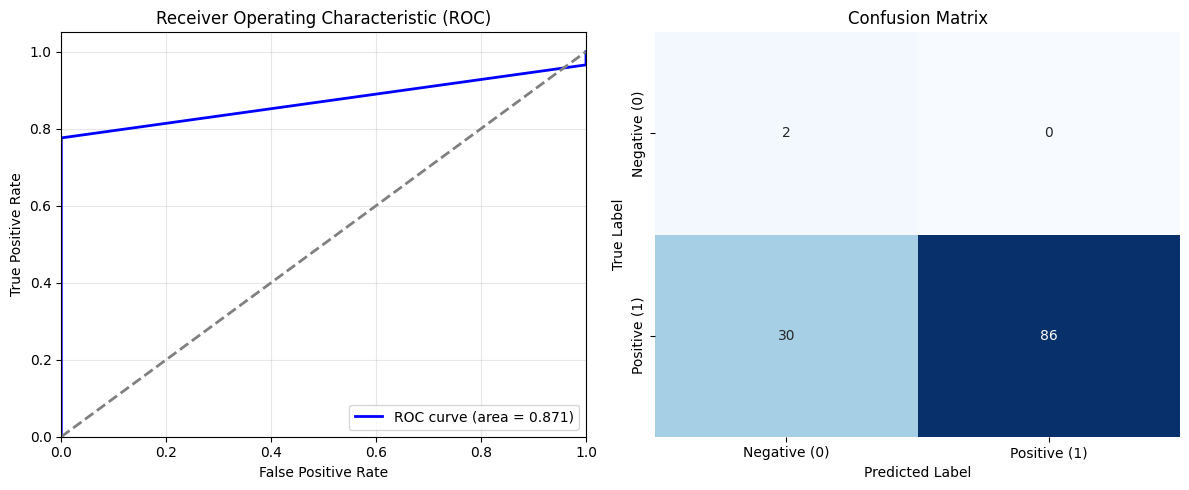

In [6]:
# 1. Plot ROC Curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
if not np.isnan(auc):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {auc:.3f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
else:
    plt.text(0.5, 0.5, 'Need both positive and negative labels\nfor ROC curve', 
             horizontalalignment='center', verticalalignment='center')
    plt.title('ROC Curve')

# 2. Plot Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()